# 06 · 5-Year Mortality Classification

Probability of death (any cause) within 60 months, from variables known at diagnosis.

1. Stratified 80/20 split, same test patients as notebook 07.
2. Label: died ≤ 60 months = 1, followed > 60 months = 0. Alive patients followed < 60 months are excluded.
3. 5-fold CV on the training part.
4. Keep the simplest model within one standard error of the best (Hastie et al., 2009, §7.10).
5. One evaluation on the test part.

In [1]:
import sys, warnings, json
from pathlib import Path

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
                             brier_score_loss, ConfusionMatrixDisplay, confusion_matrix)
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_predict
from scipy.stats import loguniform, randint, uniform

from seer_survival import config as C
from seer_survival.data import load_clean
from seer_survival.features import INPUT_COLS
from seer_survival.targets import horizon_label
from seer_survival.models import classifier_zoo, make_classifier_pipeline
from seer_survival.training import (make_split, horizon_subset, cv_classifiers, summarise_cv, select_one_se,
                                    fit_final_classifier)
from seer_survival.evaluate import (classification_metrics, bootstrap_ci, paired_bootstrap_diff, youden_threshold,
                                    net_benefit)
from seer_survival.plots import set_style, save_fig, PALETTE

set_style()
df = load_clean()
s = make_split(df)

## 1. Building the 5-year label

In [2]:
rows = []
for part in ("train", "test"):
    y, known = horizon_label(s[f"t_{part}"], s[f"e_{part}"], C.HORIZON_MONTHS)
    rows.append({"split": part, "patients": len(y), "died <= 60m (y=1)": int(y[known].sum()),
                 "observed > 60m (y=0)": int((known & (y == 0)).sum()),
                 "excluded: censored < 60m": int((~known).sum()),
                 "event rate among labelled": y[known].mean()})
pd.DataFrame(rows).round(3)

,split,patients,died <= 60m (y=1),observed > 60m (y=0),excluded: censored < 60m,event rate among labelled
0,train,3219,366,2193,660,0.143
1,test,805,92,565,148,0.140


In [3]:
Xtr, ytr, _ = horizon_subset(s["X_train"], s["t_train"], s["e_train"])
Xte, yte, _ = horizon_subset(s["X_test"], s["t_test"], s["e_test"])
print(f"Train: {len(ytr)} labelled ({ytr.sum()} events) | Test: {len(yte)} labelled ({yte.sum()} events)")

Train: 2559 labelled (366 events) | Test: 657 labelled (92 events)


Dropping censored patients is unbiased if censoring is unrelated to prognosis, which notebook 04 suggests. Inverse-probability weighting would be the fuller alternative. The survival models in notebook 07 avoid the issue.

## 2. How much does leakage inflate performance?

Same model and folds, three set-ups:

| Set-up | Target | Inputs |
|---|---|---|
| A. leaky | `status` | 12 inputs + `survival_months` |
| B. naive | `status` | 12 inputs |
| C. correct | died ≤ 60 months | 12 inputs |

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from seer_survival.features import make_preprocessor

cv =StratifiedKFold(5, shuffle=True, random_state=C.RANDOM_STATE)

def cv_auc(X, y, leaky_time=None, model=None):
    model = model or LogisticRegression(max_iter=5000)
    aucs = []
    for tr, va in cv.split(X, y):
        prep = make_preprocessor(scale=True).fit(X.iloc[tr])
        A, B = prep.transform(X.iloc[tr]), prep.transform(X.iloc[va])
        if leaky_time is not None:
            m, sd = leaky_time[tr].mean(), leaky_time[tr].std()
            A = A.assign(survival_months=(leaky_time[tr] - m) / sd)
            B = B.assign(survival_months=(leaky_time[va] - m) / sd)
        mdl = clone(model).fit(A, y[tr])
        aucs.append(roc_auc_score(y[va], mdl.predict_proba(B)[:, 1]))
    return np.array(aucs)

X_all, e_all, t_all = s["X_train"], s["e_train"], s["t_train"]
from xgboost import XGBClassifier
xgb = XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=C.RANDOM_STATE, n_jobs=-1)
leak = pd.DataFrame({
    "A. leaky (status + survival_months)": [cv_auc(X_all, e_all, t_all).mean(), cv_auc(X_all, e_all, t_all, xgb).mean()],
    "B. naive (status, no time)": [cv_auc(X_all, e_all).mean(), cv_auc(X_all, e_all, model=xgb).mean()],
    "C. correct (5-year label)": [cv_auc(Xtr, ytr).mean(), cv_auc(Xtr, ytr, model=xgb).mean()],
}, index=["Logistic regression", "XGBoost"]).T
leak.round(3)

,Logistic regression,XGBoost
A. leaky (status + survival_months),0.864,0.873
"B. naive (status, no time)",0.744,0.736
C. correct (5-year label),0.745,0.720


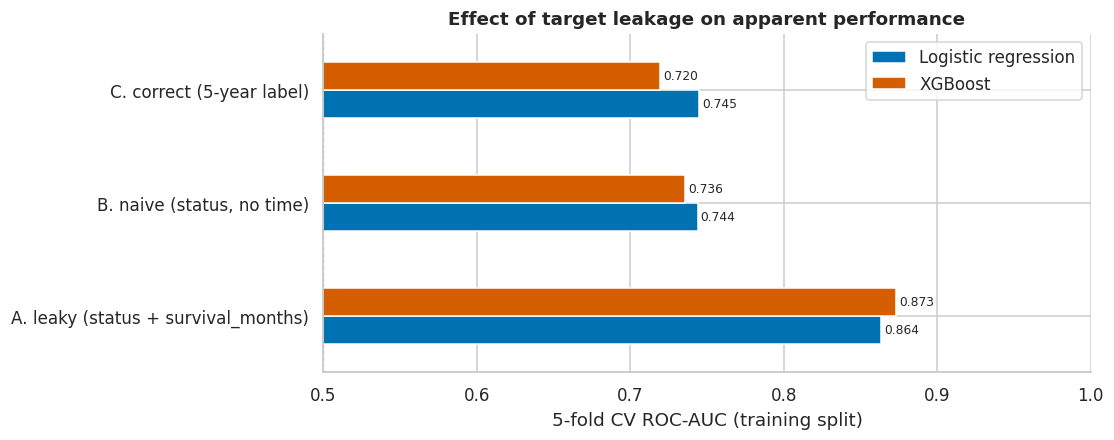

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
leak.plot.barh(ax=ax, color=[PALETTE[0], PALETTE[1]])
ax.axvline(0.5, c="grey", ls=":"); ax.set_xlim(0.5, 1.0); ax.set_xlabel("5-fold CV ROC-AUC (training split)")
ax.set_title("Effect of target leakage on apparent performance")
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f", fontsize=8, padding=2)
save_fig(fig, "06_leakage_experiment"); plt.show()

## 3. Model comparison

Eight models, from linear to tree ensembles, compared with 5-fold CV. No SMOTE or class weights, because they distort predicted probabilities (van den Goorbergh et al., 2022).

In [6]:
cv_scores, oof = cv_classifiers(Xtr, ytr)
summary = summarise_cv(cv_scores, "roc_auc")
brier = cv_scores.groupby("model")["brier"].mean()
summary["brier_mean"] = brier
summary.round(4)

,mean,sd,n_folds,se,complexity,brier_mean
model,,,,,,
LogReg (L1),0.7466,0.0157,5,0.0070,1,0.1077
LogReg (L2),0.7448,0.0180,5,0.0080,1,0.1080
Random Forest,0.7341,0.0108,5,0.0048,2,0.1091
XGBoost,0.7320,0.0157,5,0.0070,2,0.1115
HistGradBoost,0.7186,0.0223,5,0.0100,2,0.1131
LightGBM,0.7069,0.0206,5,0.0092,2,0.1167
MLP,0.7035,0.0412,5,0.0184,3,0.1213
SVM (RBF),0.6076,0.0291,5,0.0130,3,0.1154


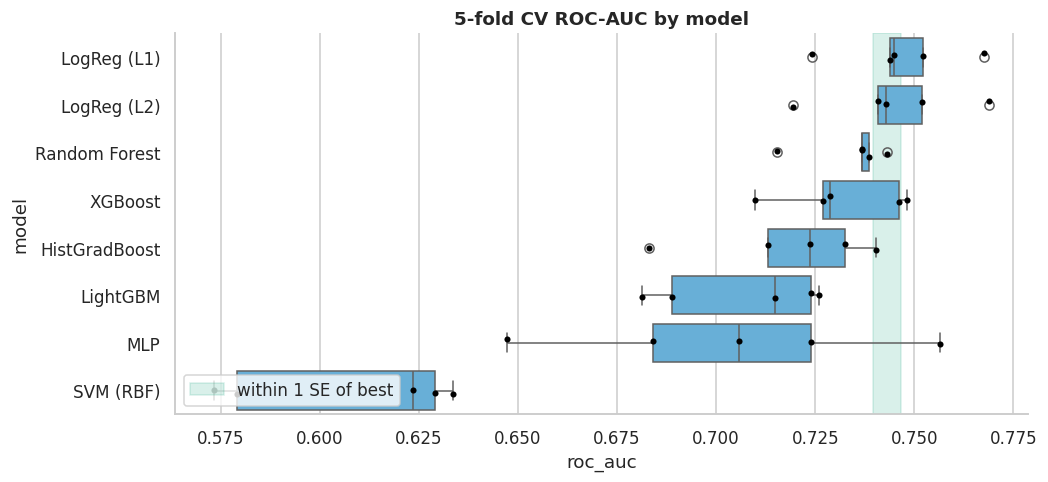

In [7]:
order = summary.index.tolist()
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.boxplot(data=cv_scores, y="model", x="roc_auc", order=order, color=PALETTE[5], ax=ax)
sns.stripplot(data=cv_scores, y="model", x="roc_auc", order=order, color="k", size=4, ax=ax)
best = summary["mean"].max(); se = summary.loc[summary["mean"].idxmax(), "se"]
ax.axvspan(best - se, best, color=PALETTE[2], alpha=.15, label="within 1 SE of best")
ax.set_title("5-fold CV ROC-AUC by model"); ax.legend(loc="lower left")
save_fig(fig, "06_cv_model_comparison"); plt.show()

In [8]:
selected = select_one_se(summary)
print("Selected by the one-standard-error rule:", selected)

Selected by the one-standard-error rule: LogReg (L1)


## 4. Does tuning help?

Randomised search (40 settings, inner 5-fold CV) for XGBoost and logistic regression. The best inner-CV score is slightly optimistic.

In [9]:
search_xgb = RandomizedSearchCV(
    make_classifier_pipeline(XGBClassifier(eval_metric="logloss", n_jobs=-1, random_state=C.RANDOM_STATE), scale=False),
    {"model__n_estimators": randint(100, 800), "model__max_depth": randint(2, 6),
     "model__learning_rate": loguniform(0.01, 0.2), "model__subsample": uniform(0.6, 0.4),
     "model__colsample_bytree": uniform(0.5, 0.5), "model__min_child_weight": randint(1, 20),
     "model__reg_lambda": loguniform(0.1, 20)},
    n_iter=40, scoring="roc_auc", cv=cv, random_state=C.RANDOM_STATE, n_jobs=-1).fit(Xtr, ytr)
search_lr = RandomizedSearchCV(
    make_classifier_pipeline(LogisticRegression(solver="saga", max_iter=10000, random_state=C.RANDOM_STATE), scale=True),
    {"model__C": loguniform(1e-3, 1e2), "model__penalty": ["l1", "l2"]},
    n_iter=40, scoring="roc_auc", cv=cv, random_state=C.RANDOM_STATE, n_jobs=-1).fit(Xtr, ytr)
tune = pd.DataFrame({
    "default CV AUC": [summary.loc["XGBoost", "mean"], summary.loc["LogReg (L2)", "mean"]],
    "tuned best CV AUC": [search_xgb.best_score_, search_lr.best_score_],
}, index=["XGBoost", "Logistic regression"])
tune["gain"] = tune.iloc[:, 1] - tune.iloc[:, 0]
print("XGBoost best params:", {k.replace("model__", ""): (round(v, 4) if isinstance(v, float) else v) for k, v in search_xgb.best_params_.items()})
print("LogReg best params: ", search_lr.best_params_)
tune.round(4)

XGBoost best params: {'colsample_bytree': 0.9538, 'learning_rate': 0.0211, 'max_depth': 2, 'min_child_weight': 15, 'n_estimators': 270, 'reg_lambda': 0.2933, 'subsample': 0.9771}
LogReg best params:  {'model__C': 0.21568228019263944, 'model__penalty': 'l1'}


,default CV AUC,tuned best CV AUC,gain
XGBoost,0.7320,0.7473,0.0153
Logistic regression,0.7448,0.7471,0.0023


## 5. Final model: fit on the whole training split, evaluate once on the test split

In [10]:
clf = fit_final_classifier(selected, Xtr, ytr)
thr = youden_threshold(ytr, oof[selected])          # threshold chosen on TRAINING out-of-fold predictions
p_te = clf.predict_proba(Xte)[:, 1]
m = classification_metrics(yte, p_te, threshold=thr)
ci = {k: bootstrap_ci(f, yte, p_te)[1:] for k, f in
      {"roc_auc": roc_auc_score, "pr_auc": average_precision_score, "brier": brier_score_loss}.items()}
res = pd.Series(m).to_frame("test value")
for k, (lo, hi) in ci.items():
    res.loc[k, "95% CI"] = f"[{lo:.3f}, {hi:.3f}]"
print(f"Selected model: {selected}  | decision threshold (Youden, train OOF): {thr:.3f}")
print(f"Test prevalence: {yte.mean():.3f}  -> a random model has PR-AUC ~ {yte.mean():.3f}")
res

Selected model: LogReg (L1)  | decision threshold (Youden, train OOF): 0.147
Test prevalence: 0.140  -> a random model has PR-AUC ~ 0.140


,test value,95% CI
roc_auc,0.733571,"[0.673, 0.791]"
pr_auc,0.394022,"[0.294, 0.504]"
brier,0.103938,"[0.088, 0.122]"
log_loss,0.352713,NaN
ece,0.023456,NaN
cal_intercept,-0.022776,NaN
cal_slope,0.992706,NaN
threshold,0.147361,NaN
sensitivity,0.619565,NaN
specificity,0.743363,NaN


### Other models on the same test set

For reference only; the model choice was fixed in section 3. Differences use a paired bootstrap.

In [11]:
ref_models = ["XGBoost", "Random Forest", "LightGBM", "LogReg (L2)"]
p_ref = {n: fit_final_classifier(n, Xtr, ytr).predict_proba(Xte)[:, 1] for n in ref_models if n != selected}
p_ref["XGBoost (tuned)"] = search_xgb.best_estimator_.predict_proba(Xte)[:, 1]
rows = []
for n, p in p_ref.items():
    d = paired_bootstrap_diff(roc_auc_score, yte, p_te, p)
    rows.append({"model": n, "test AUC": roc_auc_score(yte, p), "test Brier": brier_score_loss(yte, p),
                 f"AUC({selected}) - AUC(model)": d["diff"], "95% CI": f"[{d['ci_low']:.3f}, {d['ci_high']:.3f}]",
                 "bootstrap p": d["p_two_sided"]})
pd.DataFrame(rows).round(4)

,model,test AUC,test Brier,AUC(LogReg (L1)) - AUC(model),95% CI,bootstrap p
0,XGBoost,0.7396,0.1050,-0.0060,"[-0.031, 0.018]",0.680
1,Random Forest,0.7297,0.1055,0.0038,"[-0.020, 0.026]",0.718
2,LightGBM,0.7286,0.1078,0.0049,"[-0.028, 0.040]",0.768
3,LogReg (L2),0.7333,0.1037,0.0002,"[-0.004, 0.005]",0.912
4,XGBoost (tuned),0.7276,0.1047,0.0060,"[-0.012, 0.025]",0.534


## 6. Discrimination plots

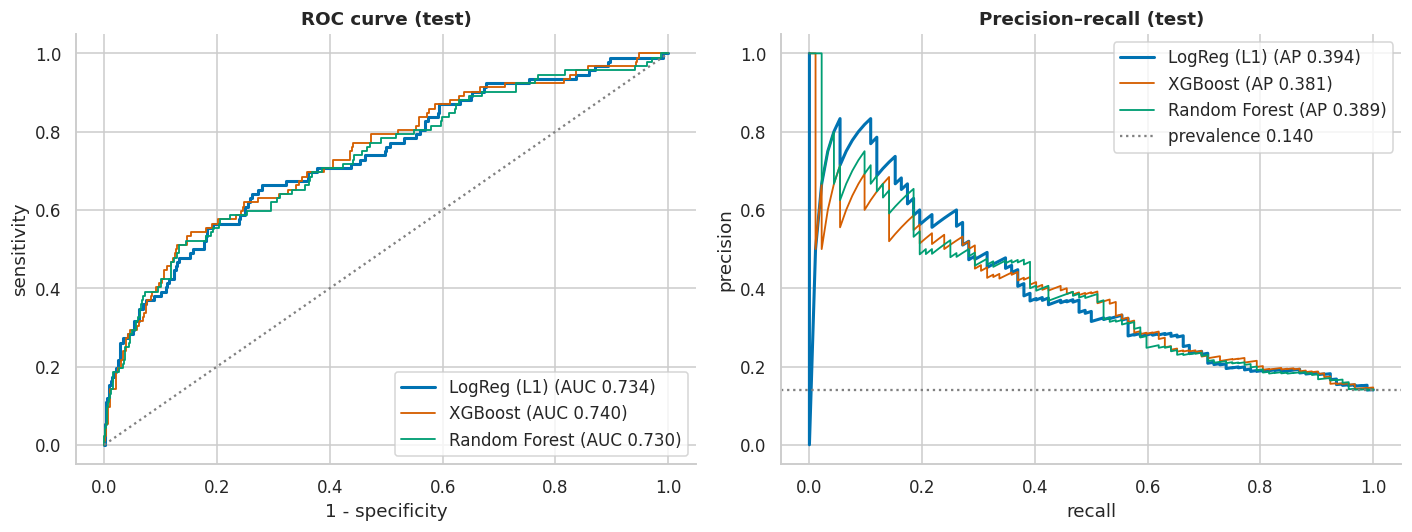

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for i, (n, p) in enumerate({selected: p_te, **{k: p_ref[k] for k in ["XGBoost", "Random Forest"] if k in p_ref}}.items()):
    fpr, tpr, _ = roc_curve(yte, p)
    axes[0].plot(fpr, tpr, c=PALETTE[i], lw=2 if i == 0 else 1.2, label=f"{n} (AUC {roc_auc_score(yte, p):.3f})")
    pr, rc, _ = precision_recall_curve(yte, p)
    axes[1].plot(rc, pr, c=PALETTE[i], lw=2 if i == 0 else 1.2, label=f"{n} (AP {average_precision_score(yte, p):.3f})")
axes[0].plot([0, 1], [0, 1], ls=":", c="grey"); axes[0].set_xlabel("1 - specificity"); axes[0].set_ylabel("sensitivity")
axes[0].set_title("ROC curve (test)"); axes[0].legend(loc="lower right")
axes[1].axhline(yte.mean(), ls=":", c="grey", label=f"prevalence {yte.mean():.3f}")
axes[1].set_xlabel("recall"); axes[1].set_ylabel("precision"); axes[1].set_title("Precision–recall (test)"); axes[1].legend()
fig.tight_layout(); save_fig(fig, "06_roc_pr_test"); plt.show()

## 7. Calibration

A predicted 20 % risk should mean about 20 deaths per 100 such patients (Van Calster et al., 2019).

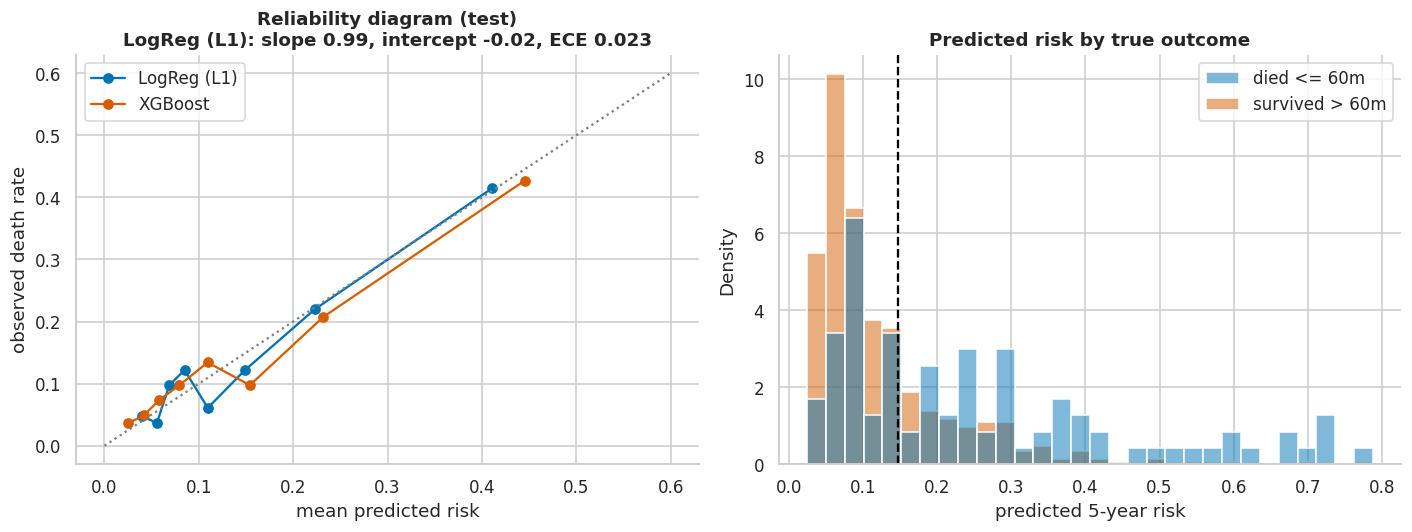

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for i, (n, p) in enumerate({selected: p_te, "XGBoost": p_ref.get("XGBoost")}.items()):
    if p is None:
        continue
    frac, mean_pred = calibration_curve(yte, p, n_bins=8, strategy="quantile")
    axes[0].plot(mean_pred, frac, "o-", c=PALETTE[i], label=n)
axes[0].plot([0, .6], [0, .6], ls=":", c="grey"); axes[0].set_xlabel("mean predicted risk"); axes[0].set_ylabel("observed death rate")
axes[0].set_title(f"Reliability diagram (test)\n{selected}: slope {m['cal_slope']:.2f}, intercept {m['cal_intercept']:.2f}, ECE {m['ece']:.3f}")
axes[0].legend()
sns.histplot(x=p_te, hue=np.where(yte == 1, "died <= 60m", "survived > 60m"), bins=30, ax=axes[1],
             palette=[PALETTE[0], PALETTE[1]], stat="density", common_norm=False, alpha=.5)
axes[1].axvline(thr, c="k", ls="--", label="threshold"); axes[1].set_title("Predicted risk by true outcome"); axes[1].set_xlabel("predicted 5-year risk")
fig.tight_layout(); save_fig(fig, "06_calibration_test"); plt.show()

## 8. Operating point and confusion matrix

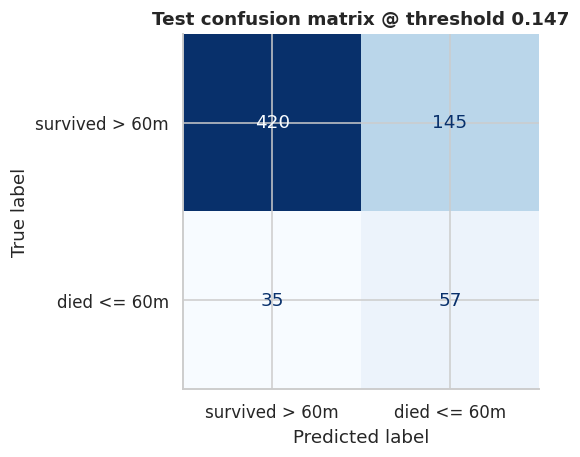

sensitivity 0.620 | specificity 0.743 | PPV 0.282 | NPV 0.923


In [14]:
fig, ax = plt.subplots(figsize=(4.8, 4.2))
ConfusionMatrixDisplay(confusion_matrix(yte, (p_te >= thr).astype(int)),
                       display_labels=["survived > 60m", "died <= 60m"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Test confusion matrix @ threshold {thr:.3f}")
save_fig(fig, "06_confusion_test"); plt.show()
print(f"sensitivity {m['sensitivity']:.3f} | specificity {m['specificity']:.3f} | PPV {m['ppv']:.3f} | NPV {m['npv']:.3f}")

With 14 % deaths, predicting "survives" for everyone gives 86 % accuracy. Accuracy alone is not informative here.

## 9. Decision curve

Net benefit across treatment thresholds (Vickers & Elkin, 2006). The model is useful where it beats both "treat all" and "treat none".

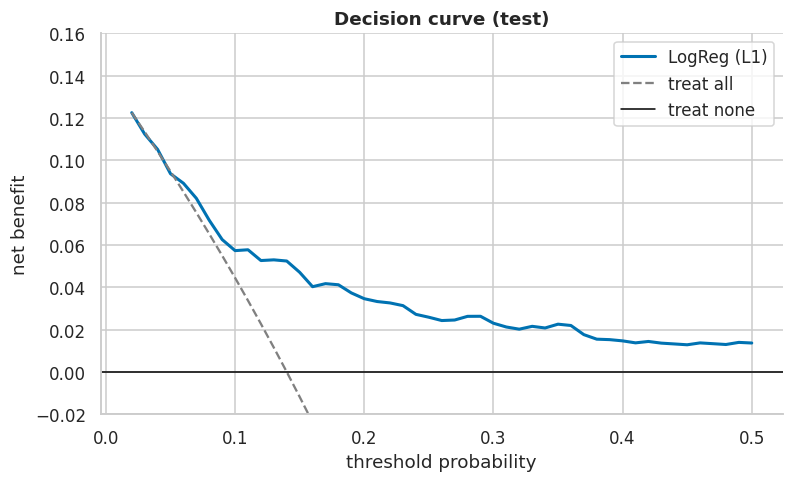

Model beats both defaults for thresholds between 0.04 and 0.50


In [15]:
thr_grid = np.linspace(0.02, 0.5, 49)
dca = net_benefit(yte, p_te, thr_grid)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(dca.threshold, dca.model, c=PALETTE[0], lw=2, label=selected)
ax.plot(dca.threshold, dca.treat_all, c="grey", ls="--", label="treat all")
ax.axhline(0, c="k", lw=1, label="treat none")
ax.set_ylim(-0.02, max(0.16, dca.model.max() + .01)); ax.set_xlabel("threshold probability"); ax.set_ylabel("net benefit")
ax.set_title("Decision curve (test)"); ax.legend()
save_fig(fig, "06_decision_curve"); plt.show()
useful = dca[(dca.model > dca.treat_all) & (dca.model > 0)].threshold
print(f"Model beats both defaults for thresholds between {useful.min():.2f} and {useful.max():.2f}")

## 10. Consistency check against the saved production artefact

`scripts/train.py` trains the model the app serves. It must reach the same selection and the same test numbers as this notebook. If it does not, something is not reproducible.

In [16]:
meta_path = C.MODELS_DIR / "metadata.json"
if meta_path.exists():
    meta = json.loads(meta_path.read_text())
    print("artefact classifier:", meta["classifier_name"], "| notebook:", selected)
    print(f"artefact test AUC: {meta['test_metrics_classifier']['roc_auc']:.4f} | notebook: {m['roc_auc']:.4f}")
    assert meta["classifier_name"] == selected
    assert abs(meta["test_metrics_classifier"]["roc_auc"] - m["roc_auc"]) < 1e-6
    print("Consistent.")
else:
    print("Run `python scripts/train.py` to create the artefacts, then re-run this cell.")

artefact classifier: LogReg (L1) | notebook: LogReg (L1)
artefact test AUC: 0.7336 | notebook: 0.7336
Consistent.


## Findings

- **Leakage:** adding `survival_months` raises CV AUC from 0.745 to 0.864 (logistic) and from 0.720 to 0.873 (XGBoost).
- **Model comparison:** L1 logistic regression has the best CV AUC (0.747) and Brier score, and is selected. RF (0.734) and XGBoost (0.732) are close; SVM and MLP are worse.
- **Tuning:** tuned XGBoost reaches 0.747 in CV but 0.728 on the test set, below its default (0.740).

Test results for the selected model (657 patients, 92 deaths):

| Metric | Value |
|---|---|
| ROC-AUC | 0.734 (0.673–0.791) |
| PR-AUC | 0.394 (prevalence 0.140) |
| Brier | 0.104 |
| Calibration slope / intercept | 0.99 / −0.02 |
| Sensitivity / specificity at 0.147 | 0.62 / 0.74 |

- No other model differs significantly on the test set (largest AUC gap 0.006).
- Cruz-Fernandez et al. (2026) report 0.75–0.78 on this cohort with a different feature set and split.